# 📊 Generated Queries — Analysis Dashboard
**Source:** `generated_queries.json`  
Top-level keys: `PANDAS` | `SQL` — each is a dict of entries with `status`, `tables`, and `data.queries[]`.

In [1]:
import json, collections
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor':   '#2e3250', 'axes.labelcolor': '#c8cde8',
    'xtick.color': '#8890b5',      'ytick.color': '#8890b5',
    'text.color':  '#c8cde8',      'grid.color':  '#2e3250',
    'grid.linestyle': '--',        'font.family': 'monospace',
    'axes.titlesize': 13,          'axes.labelsize': 11,
    'axes.titleweight': 'bold',
})

C_SUCCESS = '#4ade80'
C_FAIL    = '#f87171'
C_PANDAS  = '#60a5fa'
C_SQL     = '#f59e0b'
C_DIFF    = {'simple': '#a78bfa', 'hard': '#60a5fa', 'challenging': '#f87171'}
C_NTBL    = ['#818cf8', '#60a5fa', '#34d399', '#fbbf24', '#f87171', '#e879f9']

def bar_labels(ax, bars, fmt='{:,.0f}', pad_frac=0.01, color='white', fontsize=9):
    max_h = max((b.get_height() for b in bars), default=1)
    for bar in bars:
        h = bar.get_height()
        if h == 0: continue
        ax.text(bar.get_x()+bar.get_width()/2, h+max_h*pad_frac,
                fmt.format(h), ha='center', va='bottom', fontsize=fontsize, color=color)

print('Setup complete')

Setup complete


In [2]:
# ── Load & flatten ─────────────────────────────────────────────────────────
with open(r'D:\orqa\socrata\nyc\candidates_discovery\generated_queries.json', 'r') as f:
    raw = json.load(f)

records = []
for lang, entries in raw.items():          # 'PANDAS' or 'SQL'
    for idx, entry in entries.items():
        ok     = entry.get('status') == 'success'
        n_tbl  = len(entry.get('tables', {}))
        qs     = (entry.get('data') or {}).get('queries', [])

        if not qs:
            # failed entry — the LLM call returned no queries
            records.append({'language': lang, 'success': False,
                            'num_tables': n_tbl, 'difficulty': None, 'keywords': []})
        else:
            for q in qs:
                records.append({
                    'language':   lang,
                    'success':    ok,
                    'num_tables': n_tbl,
                    'difficulty': q.get('difficulty'),
                    'keywords':   list((q.get('keywords') or {}).keys()),
                })

df   = pd.DataFrame(records)
df_ok = df[df['success']].copy()          # successful queries only (have difficulty/keywords)

print(f'Total records  : {len(df):,}')
print(f'  Success      : {df["success"].sum():,}')
print(f'  Failed       : {(~df["success"]).sum():,}')
print(f'Languages      : {df["language"].value_counts().to_dict()}')
print(f'Difficulties   : {df_ok["difficulty"].value_counts().to_dict()}')
print(f'Tables range   : {df["num_tables"].min()} – {df["num_tables"].max()}')
df.head(4)

Total records  : 368
  Success      : 284
  Failed       : 84
Languages      : {'SQL': 229, 'PANDAS': 139}
Difficulties   : {'challenging': 124, 'simple': 82, 'hard': 78}
Tables range   : 0 – 6


,language,success,num_tables,difficulty,keywords
0,PANDAS,True,2,challenging,"[groupby, merge, sort_values]"
1,PANDAS,False,2,None,[]
2,PANDAS,False,2,None,[]
3,PANDAS,False,2,None,[]


---
## 1 · Overall Success vs Failed

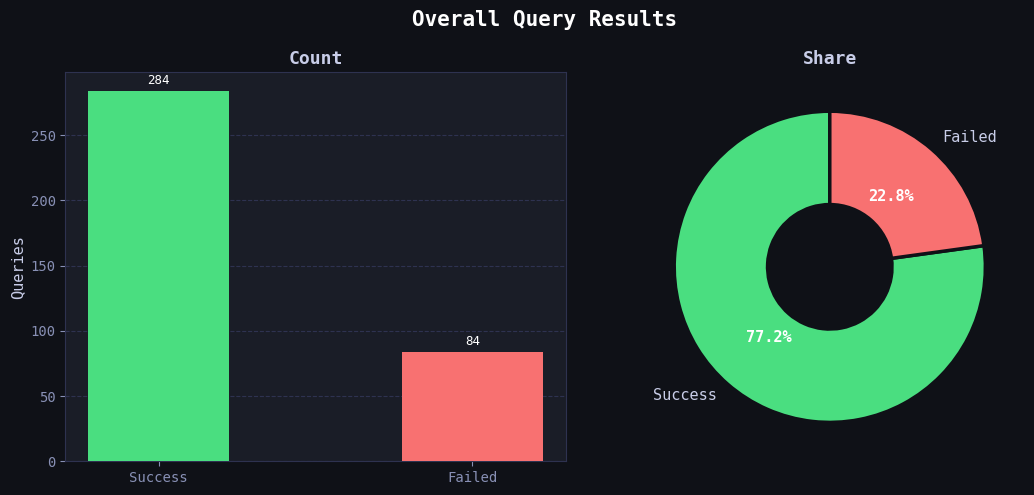

In [3]:
counts = df['success'].value_counts().reindex([True, False], fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), facecolor='#0f1117')
fig.suptitle('Overall Query Results', fontsize=15, fontweight='bold', color='white')

bars = ax1.bar(['Success', 'Failed'], counts.values,
               color=[C_SUCCESS, C_FAIL], width=0.45, zorder=3)
ax1.set_ylabel('Queries'); ax1.set_title('Count')
ax1.grid(axis='y', zorder=0); ax1.set_axisbelow(True)
bar_labels(ax1, bars)

wedges, texts, autotexts = ax2.pie(
    counts.values, labels=['Success', 'Failed'],
    colors=[C_SUCCESS, C_FAIL], autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor': '#0f1117', 'linewidth': 2.5},
    textprops={'color': '#c8cde8', 'fontsize': 11},
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('Share')

plt.tight_layout(); plt.show()

---
## 2 · Success / Failed by Language (PANDAS vs SQL)

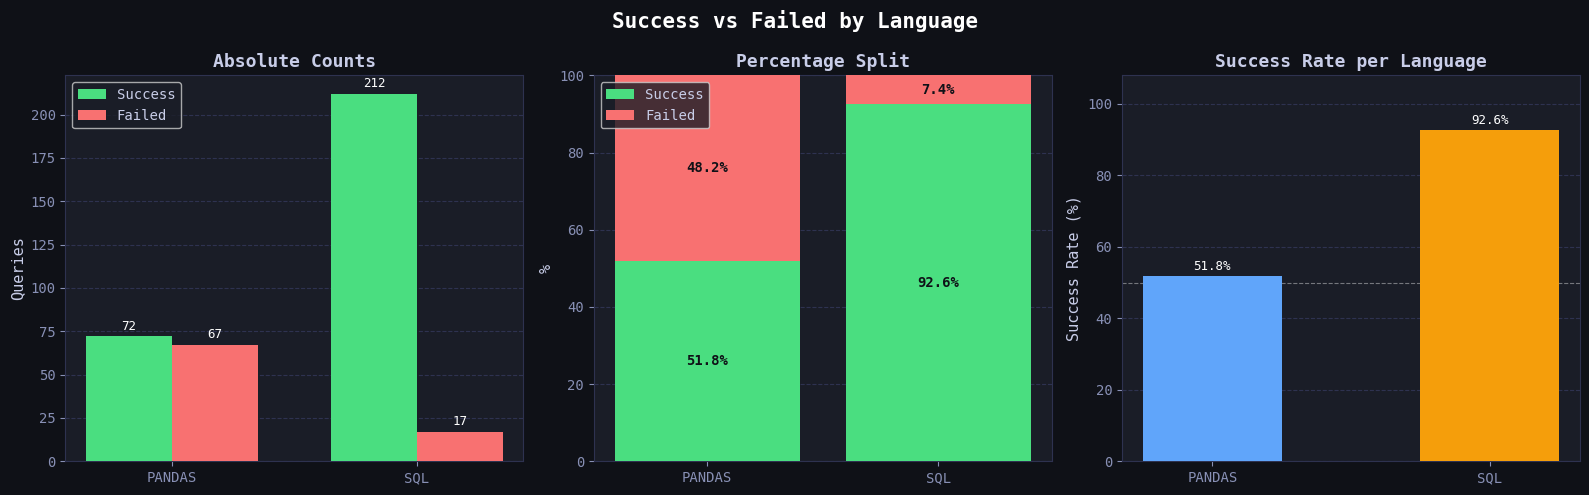

In [4]:
ls = (
    df.groupby(['language', 'success']).size().unstack(fill_value=0)
      .rename(columns={True: 'Success', False: 'Failed'})
)
for c in ['Success', 'Failed']:
    if c not in ls: ls[c] = 0

langs  = ls.index.tolist()
x, w   = np.arange(len(langs)), 0.35
totals = ls['Success'] + ls['Failed']
ps = ls['Success'] / totals * 100
pf = ls['Failed']  / totals * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0f1117')
fig.suptitle('Success vs Failed by Language', fontsize=15, fontweight='bold', color='white')

# Grouped
ax = axes[0]
b1 = ax.bar(x-w/2, ls['Success'], w, label='Success', color=C_SUCCESS, zorder=3)
b2 = ax.bar(x+w/2, ls['Failed'],  w, label='Failed',  color=C_FAIL,    zorder=3)
ax.set_xticks(x); ax.set_xticklabels(langs)
ax.set_title('Absolute Counts'); ax.set_ylabel('Queries')
ax.legend(); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)
bar_labels(ax, list(b1)+list(b2))

# 100% stacked
ax2 = axes[1]
ax2.bar(langs, ps, label='Success', color=C_SUCCESS, zorder=3)
ax2.bar(langs, pf, bottom=ps, label='Failed', color=C_FAIL, zorder=3)
ax2.set_ylim(0, 100); ax2.set_ylabel('%'); ax2.set_title('Percentage Split')
ax2.legend(); ax2.grid(axis='y', zorder=0); ax2.set_axisbelow(True)
for i, (s, f) in enumerate(zip(ps, pf)):
    if s > 4: ax2.text(i, s/2,   f'{s:.1f}%', ha='center', va='center', fontweight='bold', color='#0f1117', fontsize=10)
    if f > 4: ax2.text(i, s+f/2, f'{f:.1f}%', ha='center', va='center', fontweight='bold', color='#0f1117', fontsize=10)

# Success rate bar
ax3 = axes[2]
lc = [C_PANDAS if l == 'PANDAS' else C_SQL for l in langs]
bars3 = ax3.bar(langs, ps.values, color=lc, zorder=3, width=0.5)
ax3.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax3.set_ylim(0, 108); ax3.set_ylabel('Success Rate (%)')
ax3.set_title('Success Rate per Language')
ax3.grid(axis='y', zorder=0); ax3.set_axisbelow(True)
bar_labels(ax3, bars3, fmt='{:.1f}%')

plt.tight_layout(); plt.show()

---
## 3 · Number of Tables Involved

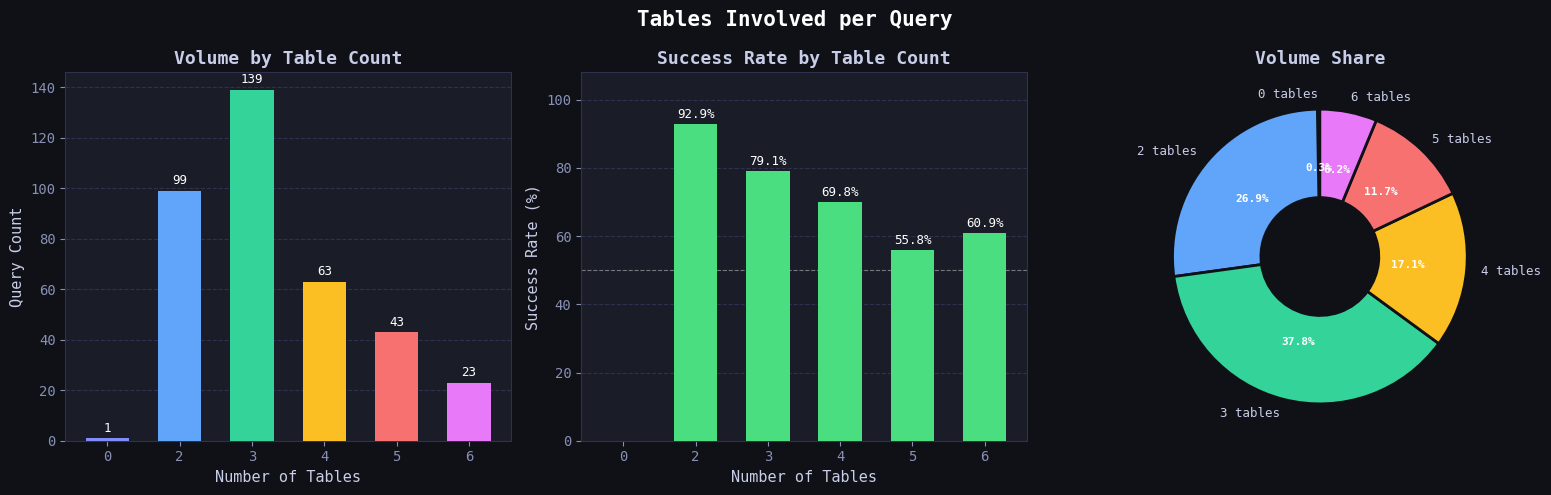

In [5]:
tbl_counts = df['num_tables'].value_counts().sort_index()
tbl_sr     = df.groupby('num_tables')['success'].mean() * 100
bar_colors = [C_NTBL[i % len(C_NTBL)] for i in range(len(tbl_counts))]
tbl_lbls   = [str(t) for t in tbl_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0f1117')
fig.suptitle('Tables Involved per Query', fontsize=15, fontweight='bold', color='white')

ax = axes[0]
bars = ax.bar(tbl_lbls, tbl_counts.values, color=bar_colors, zorder=3, width=0.6)
ax.set_xlabel('Number of Tables'); ax.set_ylabel('Query Count')
ax.set_title('Volume by Table Count')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)
bar_labels(ax, bars)

ax2 = axes[1]
sr_colors = [C_SUCCESS if v >= 50 else C_FAIL for v in tbl_sr.values]
bars2 = ax2.bar([str(t) for t in tbl_sr.index], tbl_sr.values,
                color=sr_colors, zorder=3, width=0.6)
ax2.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax2.set_ylim(0, 108); ax2.set_xlabel('Number of Tables'); ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Success Rate by Table Count')
ax2.grid(axis='y', zorder=0); ax2.set_axisbelow(True)
bar_labels(ax2, bars2, fmt='{:.1f}%')

ax3 = axes[2]
non_zero = tbl_counts[tbl_counts > 0]
wedges, texts, autotexts = ax3.pie(
    non_zero.values,
    labels=[f'{t} tables' for t in non_zero.index],
    colors=bar_colors[:len(non_zero)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': '#c8cde8', 'fontsize': 9},
)
for at in autotexts: at.set_fontweight('bold'); at.set_color('white'); at.set_fontsize(8)
ax3.set_title('Volume Share')

plt.tight_layout(); plt.show()

---
## 4 · Success / Failed by Difficulty

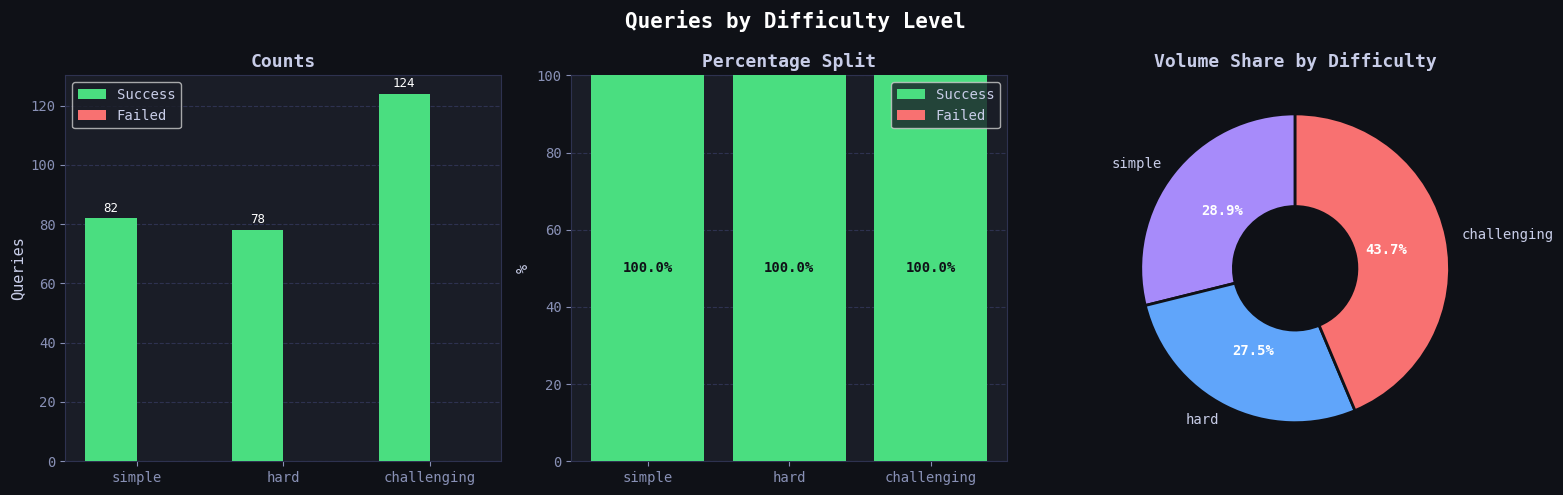

In [6]:
DIFF_ORDER = ['simple', 'hard', 'challenging']

# Count per difficulty across ALL records (failed ones have difficulty=None)
diff_all = (
    df.assign(difficulty=df['difficulty'].fillna('(failed)'))
      .groupby(['difficulty', 'success']).size().unstack(fill_value=0)
      .rename(columns={True: 'Success', False: 'Failed'})
)
for c in ['Success', 'Failed']:
    if c not in diff_all: diff_all[c] = 0

# Ordered subset — only named difficulties
ds = diff_all.reindex(DIFF_ORDER, fill_value=0)
d_colors  = [C_DIFF[d] for d in DIFF_ORDER]
x, w      = np.arange(len(DIFF_ORDER)), 0.35
totals_d  = ds['Success'] + ds['Failed']
ps = ds['Success'] / totals_d * 100
pf = ds['Failed']  / totals_d * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0f1117')
fig.suptitle('Queries by Difficulty Level', fontsize=15, fontweight='bold', color='white')

ax = axes[0]
b1 = ax.bar(x-w/2, ds['Success'], w, label='Success', color=C_SUCCESS, zorder=3)
b2 = ax.bar(x+w/2, ds['Failed'],  w, label='Failed',  color=C_FAIL,    zorder=3)
ax.set_xticks(x); ax.set_xticklabels(DIFF_ORDER)
ax.set_title('Counts'); ax.set_ylabel('Queries')
ax.legend(); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)
bar_labels(ax, list(b1)+list(b2))

ax2 = axes[1]
ax2.bar(DIFF_ORDER, ps, label='Success', color=C_SUCCESS, zorder=3)
ax2.bar(DIFF_ORDER, pf, bottom=ps, label='Failed', color=C_FAIL, zorder=3)
ax2.set_ylim(0, 100); ax2.set_ylabel('%'); ax2.set_title('Percentage Split')
ax2.legend(); ax2.grid(axis='y', zorder=0); ax2.set_axisbelow(True)
for i, (s, f) in enumerate(zip(ps, pf)):
    if s > 5: ax2.text(i, s/2,   f'{s:.1f}%', ha='center', va='center', fontweight='bold', color='#0f1117', fontsize=10)
    if f > 5: ax2.text(i, s+f/2, f'{f:.1f}%', ha='center', va='center', fontweight='bold', color='#0f1117', fontsize=10)

ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(
    totals_d.values, labels=DIFF_ORDER, colors=d_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.6, 'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': '#c8cde8', 'fontsize': 10},
)
for at in autotexts: at.set_fontweight('bold'); at.set_color('white')
ax3.set_title('Volume Share by Difficulty')

plt.tight_layout(); plt.show()

---
## 5 · Keyword Usage by Difficulty

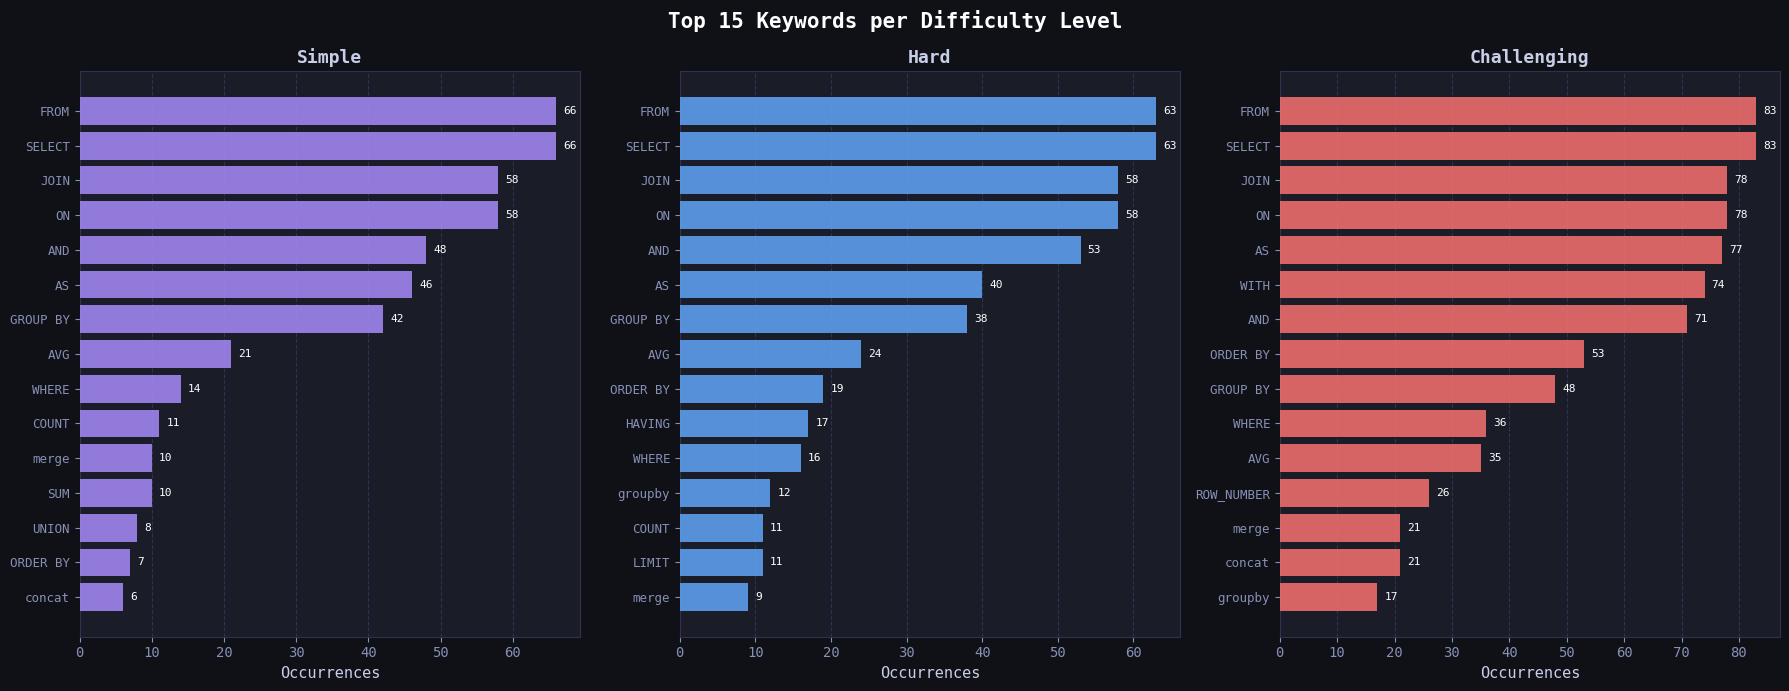

In [7]:
TOP_N = 15

kw_by_diff = {}
for diff in DIFF_ORDER:
    subset  = df_ok[df_ok['difficulty'] == diff]
    counter = collections.Counter()
    for kw_list in subset['keywords']:
        counter.update(kw_list)
    kw_by_diff[diff] = counter.most_common(TOP_N)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor='#0f1117')
fig.suptitle(f'Top {TOP_N} Keywords per Difficulty Level', fontsize=15, fontweight='bold', color='white')

for ax, diff in zip(axes, DIFF_ORDER):
    data = kw_by_diff[diff]
    if not data:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(diff.capitalize()); continue

    kws, freqs = zip(*data)
    y = np.arange(len(kws))
    bars = ax.barh(y, freqs, color=C_DIFF.get(diff, '#818cf8'), alpha=0.85, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(kws, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(diff.capitalize(), fontsize=13)
    ax.set_xlabel('Occurrences')
    ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
    for bar, val in zip(bars, freqs):
        ax.text(bar.get_width() + max(freqs)*0.015,
                bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8, color='white')

plt.tight_layout(); plt.show()

---
## 6 · Summary Table

In [8]:
summary = (
    df.assign(difficulty=df['difficulty'].fillna('(failed)'))
      .groupby(['language', 'difficulty'])
      .agg(
          total       = ('success', 'count'),
          n_success   = ('success', 'sum'),
          success_pct = ('success', lambda x: f'{x.mean()*100:.1f}%'),
          avg_tables  = ('num_tables', 'mean'),
      )
      .reset_index().round({'avg_tables': 2})
)
summary['n_failed'] = summary['total'] - summary['n_success']
summary = summary[['language','difficulty','total','n_success','n_failed','success_pct','avg_tables']]
summary.columns = ['Language','Difficulty','Total','Success','Failed','Success %','Avg Tables']
summary

,Language,Difficulty,Total,Success,Failed,Success %,Avg Tables
0,PANDAS,(failed),67,0,67,0.0%,3.96
1,PANDAS,challenging,41,41,0,100.0%,2.78
2,PANDAS,hard,15,15,0,100.0%,2.53
3,PANDAS,simple,16,16,0,100.0%,2.12
4,SQL,(failed),17,0,17,0.0%,3.59
5,SQL,challenging,83,83,0,100.0%,3.47
6,SQL,hard,63,63,0,100.0%,3.21
7,SQL,simple,66,66,0,100.0%,3.30
